In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources import grrr
from src.utils.rp_calc import estimate_return_periods

load_dotenv()

True

In [18]:
# ── Config ────────────────────────────────────────────────────────────────────
STATE = "Benue"  # "Adamawa" or "Benue"

WET_MONTHS = [8, 9, 10, 11]  # Aug–Nov
GOOGLE_RP_LEVELS = [2, 5, 7]   # Google's official pre-computed RP levels
EMPIRICAL_RP_LEVELS = [2, 3, 4, 5, 6]  # Gumbel-fitted RP levels
FS_RP_LEVELS = [3, 4, 5]       # Floodscan RP levels used as truth
FIGURES_DIR = "figures"

cfg = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR = cfg["analysis_end_year"]

## Load data

In [19]:
# Top 10 gauges by Spearman ρ from notebook 19
df_top10 = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/model_comparison/{STATE.lower()}_top10_gauges.parquet"
)
gauge_ids = df_top10["gauge_id"].tolist()
print(f"Top 10 gauges for {STATE}:")
df_top10

Top 10 gauges for Benue:


,gauge_id,quality_verified,is_benue,best_r,best_lag,n_obs
0,hybas_1120904990,False,True,0.666473,-4,3172
1,hybas_1120910440,False,True,0.663442,-4,3172
2,hybas_1120911340,True,True,0.662192,-4,3172
3,hybas_1120905450,False,False,0.661731,-3,3172
4,hybas_1120910640,False,False,0.661642,-4,3172
5,hybas_1121997090,False,False,0.661379,-4,3172
6,hybas_1120911010,False,False,0.661274,-4,3172
7,hybas_1120911330,False,False,0.660564,-4,3172
8,hybas_1120908780,True,True,0.658818,-2,3172
9,hybas_1120906580,False,True,0.658634,-2,3172


In [20]:
# Google GRRR reanalysis — wet-season annual max per gauge per year
ds_ra = grrr.load_reanalysis(gauge=gauge_ids)
df_ra = grrr.process_reanalysis(ds_ra)
df_ra["date"] = pd.to_datetime(df_ra["valid_time"]).dt.normalize()
df_ra["year"] = df_ra["date"].dt.year
df_ra["month"] = df_ra["date"].dt.month

df_annual = (
    df_ra[
        df_ra["month"].isin(WET_MONTHS)
        & df_ra["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ]
    .groupby(["gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)
eval_years = sorted(df_annual["year"].unique())
print(f"Annual maxima: {len(eval_years)} years ({min(eval_years)}–{max(eval_years)}), {df_annual['gauge_id'].nunique()} gauges")

Annual maxima: 26 years (1998–2023), 10 gauges


In [21]:
# Floodscan event years from trigger matrix (source of truth)
trigger_matrix_blob = f"{PROJECT_PREFIX}/processed/trigger_matrix/{STATE.lower()}_trigger_matrix.parquet"
df_trig = stratus.load_parquet_from_blob(trigger_matrix_blob)

fs_event_years = {
    rp: set(df_trig[df_trig[f"fs_{rp}yr"] == 1]["year"])
    for rp in FS_RP_LEVELS
}
for rp, years in fs_event_years.items():
    print(f"Floodscan {rp}-yr event years: {sorted(years)}")

Floodscan 3-yr event years: [1998, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2022]
Floodscan 4-yr event years: [2012, 2014, 2015, 2016, 2019, 2022]
Floodscan 5-yr event years: [2012, 2014, 2015, 2019, 2022]


In [22]:
# ── Shared grid-search helper ─────────────────────────────────────────────────
def run_grid_search(exceedance_pivot, rp_levels, eval_years, fs_event_years):
    """For each (N, RP_level, FS_RP_level), compute POD / FAR / F1.

    exceedance_pivot: dict {rp_level: pd.DataFrame(index=year, columns=gauge_id, values=0/1)}
    """
    n_gauges = exceedance_pivot[rp_levels[0]].shape[1]
    records = []

    for rp in rp_levels:
        pivot = exceedance_pivot[rp].reindex(index=eval_years).fillna(0)
        n_exceeded = pivot.sum(axis=1)  # number of gauges exceeding per year

        for n in range(1, n_gauges + 1):
            triggered = set(n_exceeded[n_exceeded >= n].index)

            for fs_rp in FS_RP_LEVELS:
                events = fs_event_years[fs_rp] & set(eval_years)
                tp = len(triggered & events)
                fp = len(triggered - events)
                fn = len(events - triggered)
                tn = len(set(eval_years) - triggered - events)

                pod = tp / (tp + fn) if (tp + fn) > 0 else np.nan
                far = fp / (tp + fp) if (tp + fp) > 0 else np.nan
                prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
                f1 = 2 * pod * prec / (pod + prec) if (pod and prec and (pod + prec) > 0) else np.nan

                records.append({
                    "rp_level": rp,
                    "n_gauges": n,
                    "fs_rp": fs_rp,
                    "n_activations": tp + fp,
                    "pod": pod, "far": far, "f1": f1,
                    "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                })

    return pd.DataFrame(records)


def plot_heatmaps(df_results, rp_levels, title_prefix):
    metrics = [("pod", "POD"), ("far", "FAR"), ("f1", "F1")]
    n_gauges_range = sorted(df_results["n_gauges"].unique())

    for fs_rp in FS_RP_LEVELS:
        subset = df_results[df_results["fs_rp"] == fs_rp]
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        fig.suptitle(f"{title_prefix} — vs Floodscan {fs_rp}-yr RP — {STATE}", fontsize=11)

        for ax, (metric, label) in zip(axes, metrics):
            pivot = subset.pivot(index="n_gauges", columns="rp_level", values=metric)
            pivot = pivot.reindex(index=n_gauges_range, columns=rp_levels)
            cmap = "RdYlGn" if metric != "far" else "RdYlGn_r"
            im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
            ax.set_xticks(range(len(rp_levels)))
            ax.set_xticklabels([f"{r}-yr" for r in rp_levels])
            ax.set_yticks(range(len(n_gauges_range)))
            ax.set_yticklabels(n_gauges_range)
            ax.set_xlabel("RP threshold")
            ax.set_ylabel("N gauges required")
            ax.set_title(label)
            plt.colorbar(im, ax=ax)
            for i, n in enumerate(n_gauges_range):
                for j, rp in enumerate(rp_levels):
                    val = pivot.loc[n, rp] if (n in pivot.index and rp in pivot.columns) else np.nan
                    if not np.isnan(val):
                        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

        plt.tight_layout()
        slug = title_prefix.lower().replace(" ", "_").replace("-", "_")
        plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_{slug}_fs{fs_rp}yr.png", dpi=150, bbox_inches="tight")
        plt.show()

## Part 1 — Google official RP thresholds

Use Google's pre-computed return period thresholds (2-, 5-, 7-year) for each gauge.
A gauge is considered triggered in a year if its wet-season annual max exceeds the threshold.

In [23]:
ds_google_rp = grrr.load_return_periods(gauge=gauge_ids)
df_rp_raw = ds_google_rp.to_dataframe().reset_index()

# Melt from wide (return_period_2, return_period_5, ...) to long format
rp_cols = [c for c in df_rp_raw.columns if c.startswith("return_period_")]
df_google_rp = df_rp_raw.melt(
    id_vars=["gauge_id"], value_vars=rp_cols,
    var_name="rp_raw", value_name="threshold",
)
df_google_rp["return_period"] = df_google_rp["rp_raw"].str.extract(r"(\d+)").astype(int)
df_google_rp = df_google_rp[df_google_rp["return_period"].isin(GOOGLE_RP_LEVELS)].drop(columns="rp_raw")

print(df_google_rp.groupby("return_period")["threshold"].describe().round(1))

               count    mean    std     min     25%     50%     75%     max
return_period                                                              
2               10.0  2726.7  360.1  2058.0  2445.4  2914.4  2971.3  2986.3
5               10.0  3187.1  383.8  2440.9  2904.0  3377.4  3448.6  3471.8
7               10.0  3325.7  389.3  2557.9  3044.7  3516.5  3590.9  3616.2


In [24]:
# Build exceedance pivot per Google RP level: index=year, columns=gauge_id, values=0/1
google_exceedance = {}
for rp in GOOGLE_RP_LEVELS:
    thresholds = df_google_rp[df_google_rp["return_period"] == rp].set_index("gauge_id")["threshold"]
    df_check = df_annual.join(thresholds.rename("threshold"), on="gauge_id")
    df_check["exceeded"] = (df_check["streamflow"] > df_check["threshold"]).astype(int)
    google_exceedance[rp] = df_check.pivot_table(
        index="year", columns="gauge_id", values="exceeded", aggfunc="max"
    ).reindex(columns=gauge_ids).fillna(0)

print("Gauges exceeding per year (RP=2):")
google_exceedance[2].sum(axis=1).sort_index()

Gauges exceeding per year (RP=2):


year
1998     0
1999    10
2000     0
2001    10
2002     0
2003     0
2004     0
2005     0
2006     0
2007     9
2008    10
2009     0
2010     8
2011     5
2012    10
2013     0
2014    10
2015     0
2016     0
2017     0
2018     0
2019    10
2020     0
2021     0
2022    10
2023     0
dtype: int64

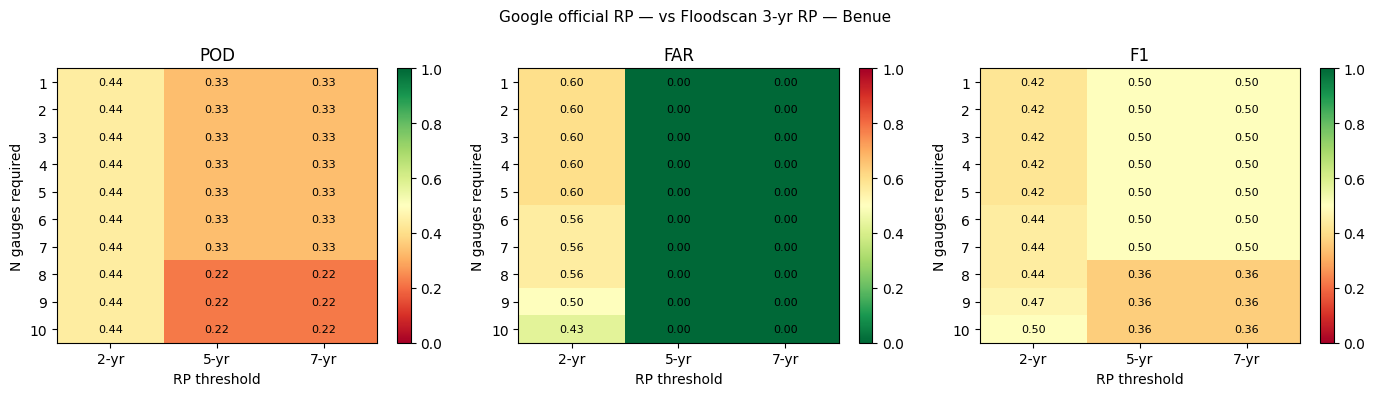

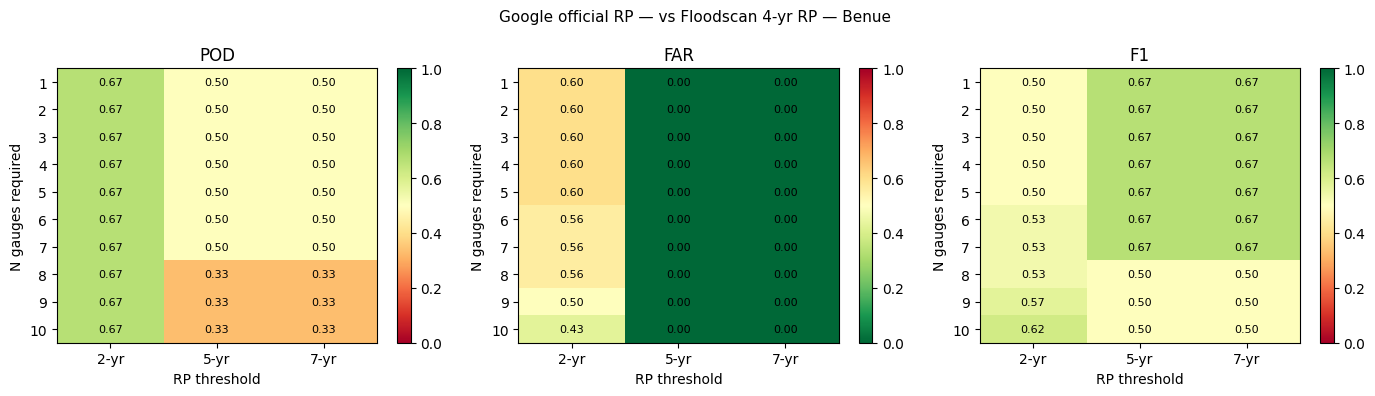

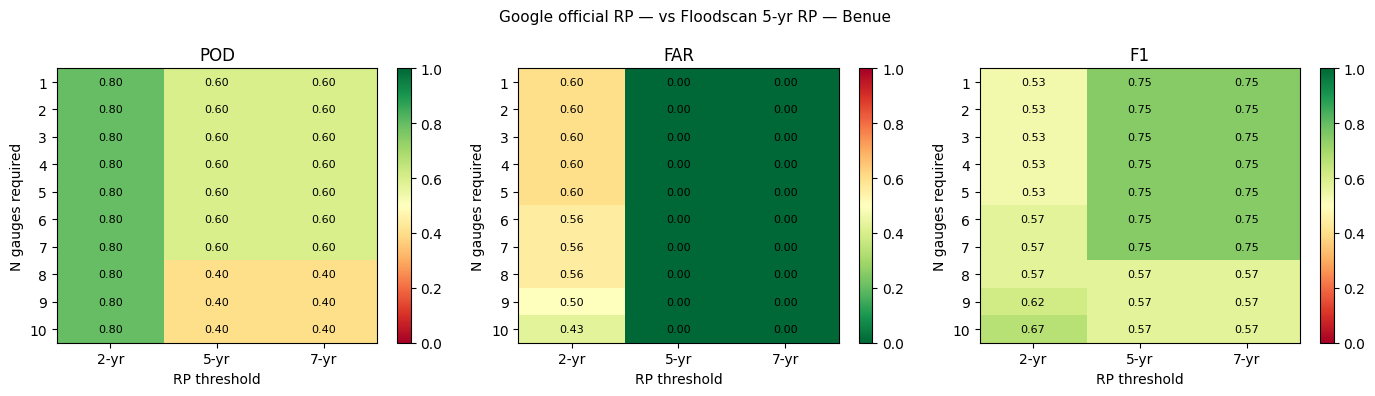

In [25]:
df_google_results = run_grid_search(google_exceedance, GOOGLE_RP_LEVELS, eval_years, fs_event_years)
plot_heatmaps(df_google_results, GOOGLE_RP_LEVELS, "Google official RP")

## Part 2 — Empirical RP thresholds (Gumbel fit)

Fit a Gumbel distribution to each gauge's wet-season annual maximum streamflow.
Extract thresholds at 2–6 year return periods and repeat the grid search.

In [26]:
# Fit Gumbel per gauge and extract thresholds for each empirical RP level
empirical_thresholds = {}  # {gauge_id: {rp: threshold}}

for gauge_id in gauge_ids:
    df_g = df_annual[df_annual["gauge_id"] == gauge_id].copy()
    if len(df_g) < 5:
        continue
    df_g["date"] = pd.to_datetime(df_g["year"].astype(str) + "-01-01")
    df_rp = estimate_return_periods(
        df_g, date_col="date", val_col="streamflow", target_rps=EMPIRICAL_RP_LEVELS,
    )
    empirical_thresholds[gauge_id] = df_rp.set_index("return_period")["value"].to_dict()

# Show fitted thresholds
df_emp_thresh = pd.DataFrame(empirical_thresholds).T
df_emp_thresh.index.name = "gauge_id"
print(f"Empirical thresholds for {len(df_emp_thresh)} gauges:")
df_emp_thresh.round(1)

Empirical thresholds for 10 gauges:


,2,3,4,5,6
gauge_id,,,,,
hybas_1120904990,2784.0,3006.8,3149.3,3254.9,3338.8
hybas_1120910440,2682.8,2892.5,3026.6,3126.0,3204.9
hybas_1120911340,2693.0,2902.9,3037.3,3136.7,3215.9
hybas_1120905450,1911.6,2069.0,2169.8,2244.3,2303.7
hybas_1120910640,2786.6,3001.4,3138.8,3240.6,3321.5
hybas_1121997090,2768.6,2981.8,3118.2,3219.2,3299.6
hybas_1120911010,2773.4,2987.3,3124.2,3225.6,3306.2
hybas_1120911330,2731.7,2943.0,3078.2,3178.3,3257.9
hybas_1120908780,2096.8,2263.6,2370.3,2449.3,2512.1


In [27]:
# Build exceedance pivot per empirical RP level
empirical_exceedance = {}
for rp in EMPIRICAL_RP_LEVELS:
    thresh_series = pd.Series({g: empirical_thresholds[g][rp] for g in empirical_thresholds})
    df_check = df_annual.join(thresh_series.rename("threshold"), on="gauge_id")
    df_check["exceeded"] = (df_check["streamflow"] > df_check["threshold"]).astype(int)
    empirical_exceedance[rp] = df_check.pivot_table(
        index="year", columns="gauge_id", values="exceeded", aggfunc="max"
    ).reindex(columns=gauge_ids).fillna(0)

print("Gauges exceeding per year (empirical RP=2):")
empirical_exceedance[2].sum(axis=1).sort_index()

Gauges exceeding per year (empirical RP=2):


year
1998     7
1999    10
2000     0
2001    10
2002     0
2003     9
2004     8
2005     0
2006     0
2007    10
2008    10
2009     0
2010    10
2011    10
2012    10
2013     0
2014    10
2015     0
2016     0
2017     0
2018    10
2019    10
2020     9
2021     0
2022    10
2023     0
dtype: int64

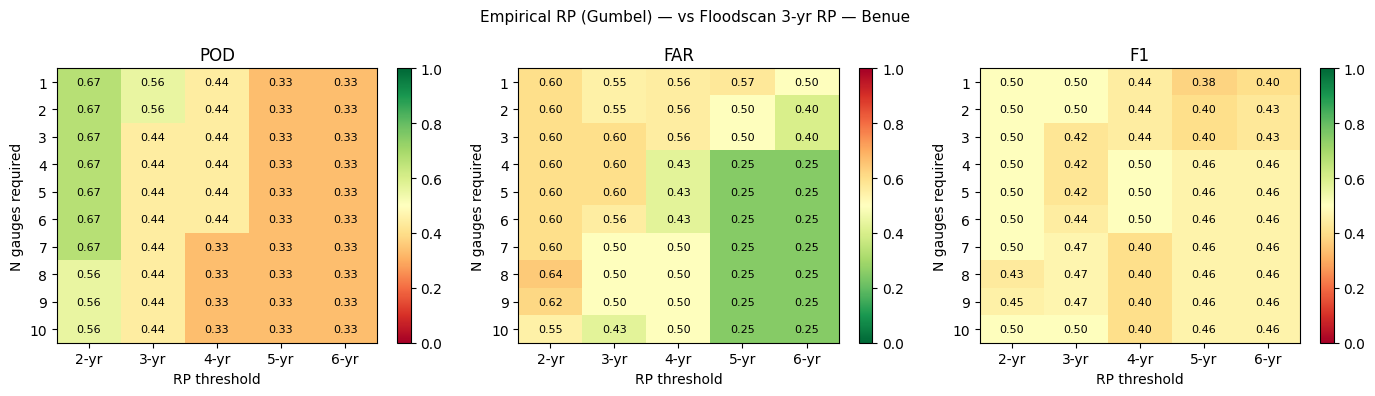

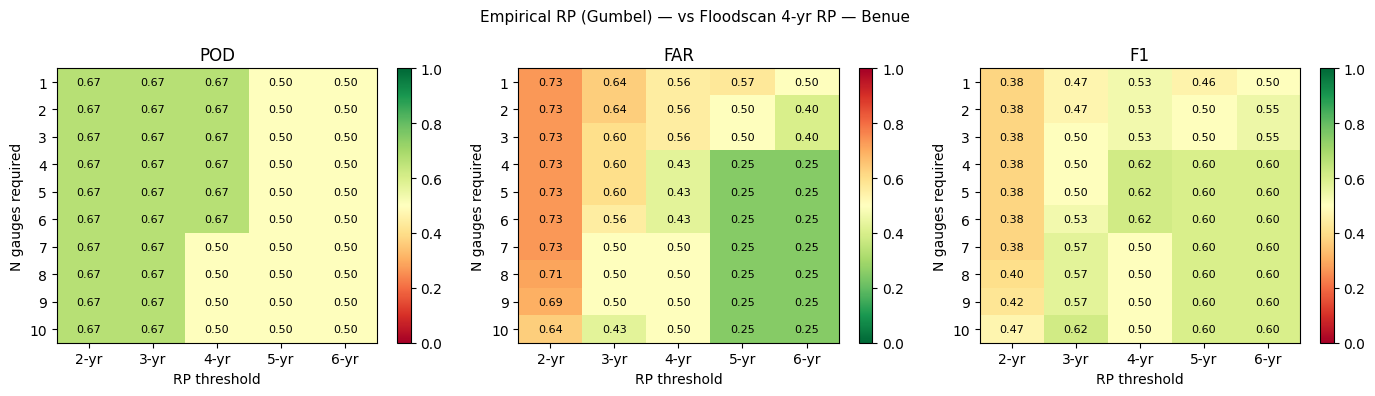

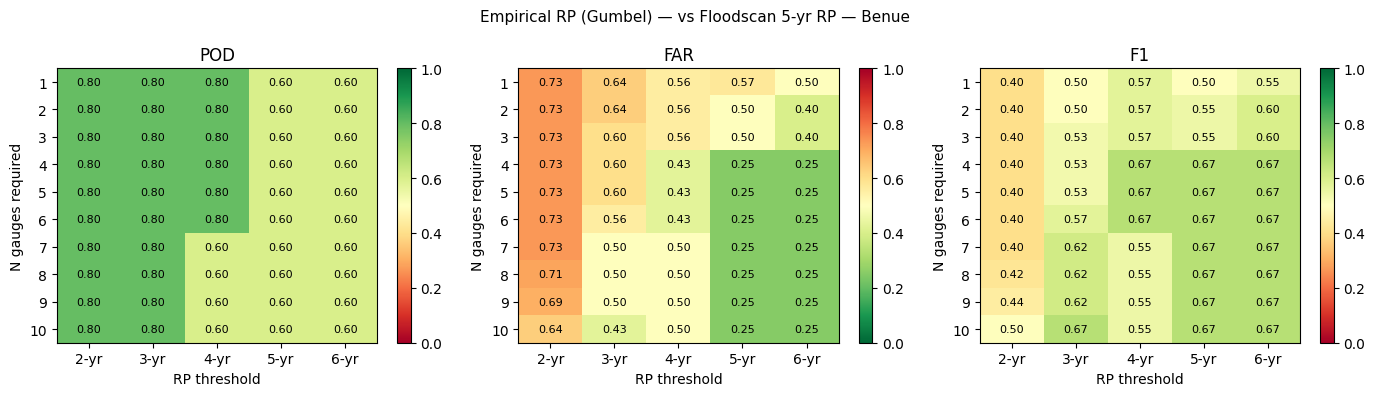

In [28]:
df_empirical_results = run_grid_search(empirical_exceedance, EMPIRICAL_RP_LEVELS, eval_years, fs_event_years)
plot_heatmaps(df_empirical_results, EMPIRICAL_RP_LEVELS, "Empirical RP (Gumbel)")

## Best configurations

Best (N, RP_level) pair by F1 score for each Floodscan RP level and threshold approach.

In [29]:
rows = []
for label, df_res in [("Google official RP", df_google_results), ("Empirical RP (Gumbel)", df_empirical_results)]:
    for fs_rp in FS_RP_LEVELS:
        sub_fs = df_res[df_res["fs_rp"] == fs_rp]
        best_idx = sub_fs.groupby(["rp_level", "n_gauges"])["f1"].mean().idxmax()
        best_rp, best_n = best_idx
        sub = sub_fs[(sub_fs["rp_level"] == best_rp) & (sub_fs["n_gauges"] == best_n)]
        rows.append({
            "Approach": label,
            "Floodscan RP": f"{fs_rp}-yr",
            "Best RP level": f"{best_rp}-yr",
            "N gauges required": best_n,
            "F1": round(sub["f1"].iloc[0], 3),
            "POD": round(sub["pod"].iloc[0], 3),
            "FAR": round(sub["far"].iloc[0], 3),
            "Activations": int(sub["n_activations"].iloc[0]),
        })

pd.DataFrame(rows)

,Approach,Floodscan RP,Best RP level,N gauges required,F1,POD,FAR,Activations
0,Google official RP,3-yr,2-yr,10,0.500,0.444,0.429,7
1,Google official RP,4-yr,5-yr,1,0.667,0.500,0.000,3
2,Google official RP,5-yr,5-yr,1,0.750,0.600,0.000,3
3,Empirical RP (Gumbel),3-yr,2-yr,1,0.500,0.667,0.600,15
4,Empirical RP (Gumbel),4-yr,3-yr,10,0.615,0.667,0.429,7
5,Empirical RP (Gumbel),5-yr,3-yr,10,0.667,0.800,0.429,7
